## About this review copy

Main EnerMap modelling sequence. Existing results are retained without rerunning calculations.

Prepared from existing source and saved outputs; **no research calculations were rerun**. Address-level tables, interactive payloads and personal paths have been removed where detected. Static PNG plots are retained unchanged. Source markdown may describe earlier runs: consult [interpretation notes](../../docs/INTERPRETATION.md) and the saved outputs together. Input data are intentionally excluded.


In [ ]:
# Review copy: read the saved outputs without executing the research pipeline.
import os
if os.environ.get("ENERMAP_ENABLE_MODEL_RUN") != "1":
    raise RuntimeError("This showcase contains saved outputs. Raw data and third-party engines are excluded. Read the notebook; do not Run All for the presentation.")
import sys
from pathlib import Path
_repo = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "config.py").exists())
sys.path.insert(0, str(_repo))


# 05 · The archetype tier: representative dwellings, stock scaling, first meter comparison

Two tiers make the UBEM usable by a council:

* **archetype tier** — a few hundred representative dwellings (each construction
  sub-archetype × three size classes × stratified household draws), simulated in
  minutes. Their **intensities** (kWh/m²) are applied to every dwelling of the same
  sub-archetype and size class through its own floor area and heating system, then
  aggregated to LSOA / ward. This tier drives calibration (notebook 06) and scenario
  screening;
* **dwelling tier** — every one of the 57,300 dwellings simulated with its own geometry
  (notebook 08; about 6 h on 32 cores with the weather cache, checkpointed).

In [1]:
import matplotlib.pyplot as plt; plt.rcParams["savefig.dpi"] = 300   # publication resolution for every saved figure
import sys, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd()))
from config import *              # paths + modelling choices (edit config.py, not the notebooks)
import pbc_helpers as H
H.setup_plots()

import ukubem
from ukubem.engine import PBE, run_building, annual_summary
from ukubem.geometry import UKGeometryAssumptions, build_bui, rdsap_default_window_area
from ukubem.schedules import sample_household, dwelling_schedule, deterministic_schedule
from ukubem.systems import delivered_energy, SYSTEM_DEFAULTS
from ukubem.runner import simulate_rows, simulate_stock, aggregate_lsoa, mape
pybui = PBE.load(PBE_SRC)
UBEM_OUT = OUT / "ubem"; UBEM_OUT.mkdir(exist_ok=True)
FIG_UBEM = FIG / "ubem"; FIG_UBEM.mkdir(exist_ok=True)
print(f"pyBuildingEnergy from {PBE_SRC}   |   cores: {N_JOBS}")

pyBuildingEnergy from LOCAL_PATH/src   |   cores: 32


In [2]:
inputs = pd.read_parquet(EXPORT_DIR / "dwelling_inputs.parquet")
table = pd.read_parquet(TABLE_NUMERIC); labels = pd.read_parquet(TABLE_LABELS)
bench_lsoa = pd.read_csv(BENCH_LSOA).rename(columns=lambda c: c.replace("_kwh", "_kWh"))
A = UKGeometryAssumptions()
N_REAL = 3                                    # stratified household draws per representative (Latin hypercube over regime and thermostat quantiles)
# size classes: terciles of floor area within each construction sub-archetype
inputs["size_class"] = inputs.groupby("construction_sa")["floor_area_final"].transform(
    lambda s: pd.qcut(s.rank(method="first"), 3, labels=["S", "M", "L"]).astype(str) if len(s) >= 9 else "M").astype(str)
grp = inputs.groupby(["construction_sa", "size_class"], observed=True)
reps = []
for (sa, sc), g in grp:
    med = g["floor_area_final"].median()
    reps.append({"construction_sa": sa, "size_class": sc, "n": len(g), "dwelling_id": int((g["floor_area_final"] - med).abs().idxmin())})
reps = pd.DataFrame(reps)
print(f"{len(reps)} representatives (sub-archetype × size class) covering {reps['n'].sum():,} dwellings; "
      f"{len(reps) * N_REAL} stochastic runs + {len(reps)} deterministic runs")
reps.head()

102 representatives (sub-archetype × size class) covering 57,300 dwellings; 306 stochastic runs + 102 deterministic runs


,construction_sa,size_class,n,dwelling_id
0,C.Det.1,L,1668,23909
1,C.Det.1,M,1668,8450
2,C.Det.1,S,1668,7641
3,C.Det.2,L,1190,52231
4,C.Det.2,M,1190,11114


## 1 · Simulate the representatives (all cores)

In [3]:
from joblib import Parallel, delayed
rows = inputs.loc[reps["dwelling_id"]]
t0 = time.time()
chunks = [rows.iloc[i:i + 3] for i in range(0, len(rows), 3)]
det = pd.DataFrame(sum(Parallel(n_jobs=N_JOBS)(delayed(simulate_rows)(c, str(EPW), str(PBE_SRC), A, False, SEED, 2021, None) for c in chunks), []))
sto_runs = []
for k in range(N_REAL):
    sto_runs.append(pd.DataFrame(sum(Parallel(n_jobs=N_JOBS)(delayed(simulate_rows)(c, str(EPW), str(PBE_SRC), A, True, SEED, 2021, None, False, 60, k, N_REAL) for c in chunks), [])).assign(realisation=k))
sto = pd.concat(sto_runs, ignore_index=True)
print(f"{len(det) + len(sto)} simulations in {(time.time()-t0)/60:.1f} min on {N_JOBS} cores")
det.to_parquet(UBEM_OUT / "05_representatives_deterministic.parquet"); sto.to_parquet(UBEM_OUT / "05_representatives_stochastic.parquet")
print("failures:", (det.status != "ok").sum(), (sto.status != "ok").sum())

408 simulations in 9.8 min on 32 cores
failures: 0 0


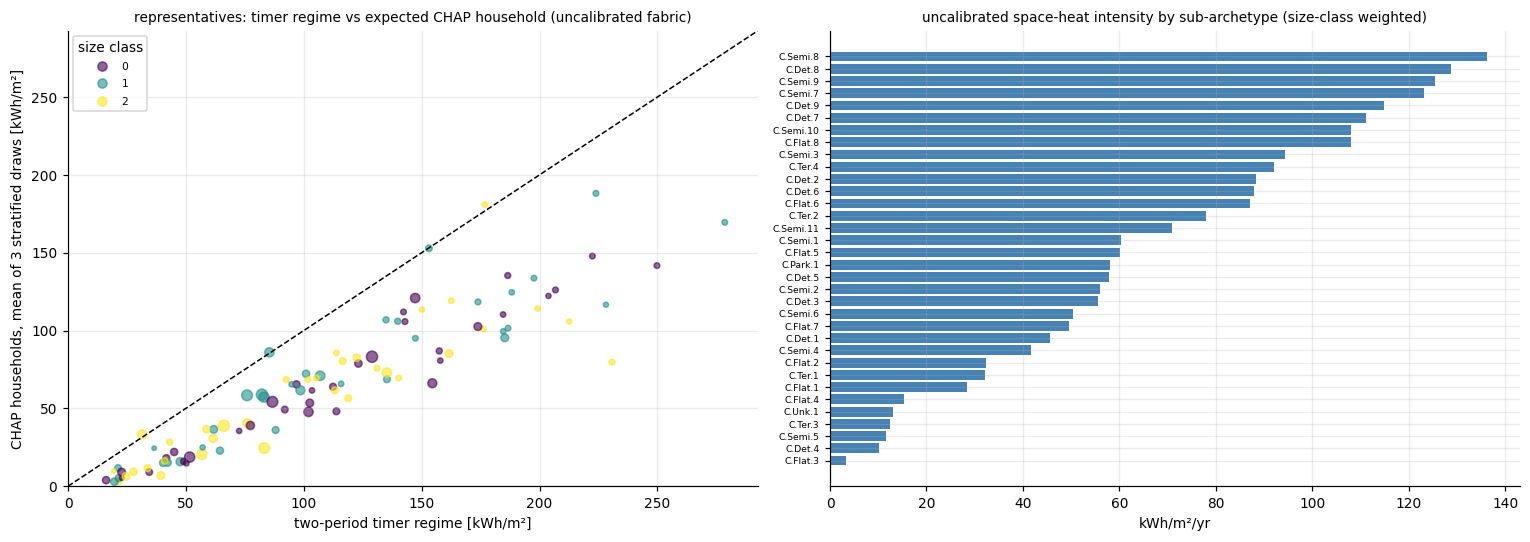

,Q_H_kWh_m2,Q_H_sd,T_op_winter,dhw_kWh,appliances_kWh,A_floor,construction_sa,size_class,n,Q_H_kWh_m2_deterministic
dwelling_id,,,,,,,,,,
50120,188.1,65.0,18.3,1490.6,3139.4,90.4,C.Semi.7,M,251,223.9
56097,180.9,74.3,19.8,1584.4,3934.0,135.5,C.Semi.8,L,243,176.9
7865,169.5,71.0,15.3,1591.7,4093.5,147.0,C.Det.8,M,222,278.6
8646,152.8,85.6,19.3,1592.2,4107.0,148.0,C.Det.6,M,440,153.1
6669,147.8,9.4,16.8,1484.1,3107.3,89.0,C.Det.8,S,222,222.4
6635,141.7,36.0,15.3,1413.5,2751.6,75.0,C.Semi.9,S,234,249.8
9470,135.3,56.2,17.3,1527.3,3344.2,100.0,C.Det.7,S,268,186.5
7146,133.6,61.2,16.7,1530.4,3364.0,101.0,C.Semi.9,M,234,197.6
691,126.0,63.6,15.6,1396.8,2667.3,72.0,C.Semi.8,S,242,206.8


In [4]:
key = reps.set_index("dwelling_id")[["construction_sa", "size_class", "n"]]
inten = (sto.groupby("dwelling_id").agg(Q_H_kWh_m2=("Q_H_kWh_m2", "mean"), Q_H_sd=("Q_H_kWh_m2", "std"), T_op_winter=("T_op_heating_season_C", "mean"),
                                        dhw_kWh=("dhw_kWh", "mean"), appliances_kWh=("appliances_kWh", "mean"), A_floor=("A_floor", "first"))
            .join(key).join(det.set_index("dwelling_id")["Q_H_kWh_m2"].rename("Q_H_kWh_m2_deterministic")))
inten.to_csv(UBEM_OUT / "05_archetype_intensities.csv")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
lim = inten[["Q_H_kWh_m2", "Q_H_kWh_m2_deterministic"]].max().max() * 1.05
sc = axes[0].scatter(inten["Q_H_kWh_m2_deterministic"], inten["Q_H_kWh_m2"], s=inten["n"] / 40 + 8, alpha=0.6, c=inten["size_class"].map({"S": 0, "M": 1, "L": 2}), cmap="viridis")
axes[0].plot([0, lim], [0, lim], "k--", lw=1); axes[0].set_xlim(0, lim); axes[0].set_ylim(0, lim)
axes[0].set_xlabel("two-period timer regime [kWh/m²]"); axes[0].set_ylabel(f"CHAP households, mean of {N_REAL} stratified draws [kWh/m²]"); axes[0].set_title("representatives: timer regime vs expected CHAP household (uncalibrated fabric)", fontsize=9)
axes[0].legend(*sc.legend_elements(), title="size class", fontsize=7, loc="upper left")
g = inten.groupby("construction_sa").apply(lambda d: np.average(d["Q_H_kWh_m2"], weights=d["n"]), include_groups=False).sort_values()
axes[1].barh(range(len(g)), g.values, color="steelblue"); axes[1].set_yticks(range(len(g))); axes[1].set_yticklabels(g.index, fontsize=6)
axes[1].set_xlabel("kWh/m²/yr"); axes[1].set_title("uncalibrated space-heat intensity by sub-archetype (size-class weighted)", fontsize=9)
plt.tight_layout(); fig.savefig(FIG_UBEM / "05_archetype_intensities.png", bbox_inches="tight"); plt.show()
inten.sort_values("Q_H_kWh_m2", ascending=False).head(12).round(1)

## 2 · Scale to the stock and compare with DESNZ 2021 (initial guess, no calibration)

Each dwelling takes the intensity of its sub-archetype × size class, times its own floor
area, then its own system family converts need to fuel. Gas is compared over gas-boiler
dwellings against mains-gas meter means, electricity over all dwellings.

archetype-tier initial guess vs DESNZ 2021: {'gas_MAPE': 0.325, 'elec_MAPE': 0.094, 'gas_bias': -0.325, 'elec_bias': 0.0, 'gas_WAPE_pct': 33.413, 'elec_WAPE_pct': 10.394, 'gas_NMBE_pct': -33.413, 'elec_NMBE_pct': -1.811, 'gas_R2_predictive': -0.635, 'elec_R2_predictive': 0.678, 'J_gas': 0.11, 'J_elec': 0.014}


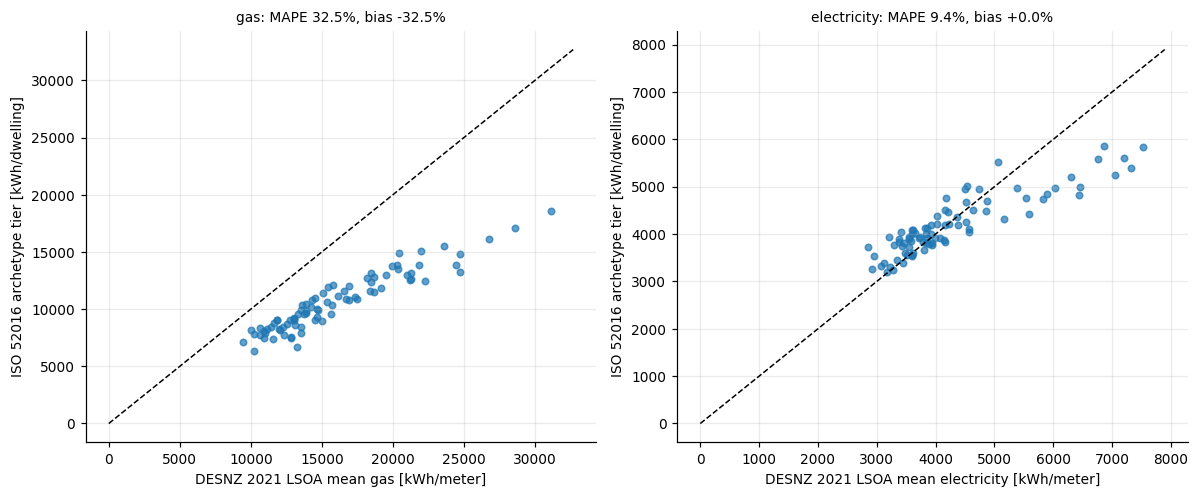

In [5]:
from ukubem.calibrate import _stock_delivered, POST_FIXED
def stock_from_intensities(inten, post=None):
    """Archetype tier -> every dwelling with the shared accounting (BREDEM usage, gas-benchmark membership rule)."""
    return _stock_delivered(inputs, inten, {**POST_FIXED, **(post or {})})

stock0 = stock_from_intensities(inten)
t0_ = aggregate_lsoa(stock0, labels, bench_lsoa)
m0 = mape(t0_); print("archetype-tier initial guess vs DESNZ 2021:", {k: round(v, 3) for k, v in m0.items()})
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, (sim, obs, ttl, key) in zip(axes, [("sim_gas_mean_kWh", "gas_mean_kWh", "gas", "gas"), ("sim_elec_mean_kWh", "elec_mean_kWh", "electricity", "elec")]):
    tt = t0_.dropna(subset=[obs, sim]); ax.scatter(tt[obs], tt[sim], s=18, alpha=0.7); lim = [0, max(tt[obs].max(), tt[sim].max()) * 1.05]; ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlabel(f"DESNZ 2021 LSOA mean {ttl} [kWh/meter]"); ax.set_ylabel("ISO 52016 archetype tier [kWh/dwelling]"); ax.set_title(f"{ttl}: MAPE {m0[key + '_MAPE']:.1%}, bias {m0[key + '_bias']:+.1%}", fontsize=9)
plt.tight_layout(); fig.savefig(FIG_UBEM / "05_initial_guess_vs_desnz.png", bbox_inches="tight"); plt.show()
stock0.to_parquet(UBEM_OUT / "05_stock_initial_guess.parquet"); t0_.to_csv(UBEM_OUT / "05_lsoa_initial_guess.csv")

**Next:** `06_calibration.ipynb` — Py-BOBYQA on the archetype tier against the DESNZ
LSOA means, then the transfer test of notebook 07.